# Sentinel — Main Pipeline Notebook

This is the **orchestrator** for the whole project. It stays *thin*: every real function lives in the
tested modules under `src/sentinel/`, and this notebook just imports them, runs each phase, and shows the
results. That keeps a single source of truth (the same code runs here, in the tests, and in CI).

**Phases**
1. Data pipeline (acquire → clean → features → label)  — *Module 3*
2. Exploratory data analysis — *Module 3*
3. News-sentiment model (fine-tuned FinBERT) — *Module 4 (stub)*
4. Volatility circuit-breaker (neural net vs XGBoost) — *Module 5 (stub)*
5. Agentic pipeline + paper-sim (LangGraph) — *Module 6 (stub)*
6. Results & ablation — *Module 7 (stub)*


## Setup (works in Google Colab **or** locally)

In Colab this clones the repo and installs dependencies. Locally it just puts `src/` on the path.
After you push the repo to GitHub, set `REPO_URL` below.


In [1]:
import os, sys, subprocess, pathlib

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/YOUR_USERNAME/sentinel-agentic-trading.git"  # <-- set after pushing
REPO_DIR = "sentinel-agentic-trading"

if IN_COLAB:
    if not pathlib.Path(REPO_DIR).exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(["pip", "-q", "install", "-r", "requirements.txt"], check=True)

# Resolve repo root and put src/ on the import path (works locally and in Colab)
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = str(ROOT / "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)
print("Repo root:", ROOT)

Repo root: /Users/rdhanase/USD/AAI-590-capstone/sentinel


In [2]:
# Import the project's own functions (the 'thick modules')
from sentinel.utils.config import load_config
from sentinel.data.acquire import acquire
from sentinel.data.clean import clean_panel
from sentinel.features.technical import build_features, FEATURE_COLUMNS
from sentinel.features.labeling import make_labels, time_split
from sentinel.eda import plots

import pandas as pd
cfg = load_config(str(ROOT / "config" / "config.yaml"))
print("Tickers:", cfg.data.tickers)
print("Window :", cfg.data.start, "->", cfg.data.end)
print("Label  : forward", cfg.label.horizon, "d vs trailing", cfg.label.lookback,
      "d", int(cfg.label.quantile * 100), "th pct")

Tickers: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'NVDA', 'WMT', 'KO', 'AMZN', 'GOOGL', 'HD', 'PG', 'UNH', 'CVX']
Window : 2010-01-01 -> 2024-12-31
Label  : forward 5 d vs trailing 252 d 80 th pct


## 1. Data pipeline

Each line below is one step, calling straight into `src/sentinel/`. (The full 16-ticker download takes a
couple of minutes; edit `config/config.yaml` to use fewer tickers for a quick run.)


In [3]:
# Acquire -> clean -> per-ticker features + labels -> one dataset
raw = acquire(cfg.data.tickers, cfg.data.start, cfg.data.end, cfg.data.interval)
clean, report = clean_panel(raw)

parts = []
for ticker, g in clean.groupby("ticker", sort=False):
    feats = build_features(g, cfg.features)
    parts.append(make_labels(feats, cfg.label.horizon, cfg.label.lookback, cfg.label.quantile))
dataset = pd.concat(parts, ignore_index=True)

labeled = dataset.dropna(subset=["label_highvol"]).copy()
labeled["label_highvol"] = labeled["label_highvol"].astype(int)
print(f"rows: {len(dataset):,} | labeled: {len(labeled):,} "
      f"| high-vol: {labeled['label_highvol'].mean():.1%} "
      f"({int(labeled['label_highvol'].sum()):,} positives)")
report

rows: 60,368 | labeled: 58,192 | high-vol: 20.5% (11,955 positives)


,ticker,duplicate_dates,nonpositive_prices,inverted_high_low,missing_close_before,rows_dropped_missing_close,n_rows_final
0,AAPL,0,0,0,0,0,3773
1,AMZN,0,0,0,0,0,3773
2,CVX,0,0,0,0,0,3773
3,GOOGL,0,0,0,0,0,3773
4,HD,0,0,0,0,0,3773
5,JNJ,0,0,0,0,0,3773
6,JPM,0,0,0,0,0,3773
7,KO,0,0,0,0,0,3773
8,MSFT,0,0,0,0,0,3773
9,NVDA,0,0,0,0,0,3773


In [4]:
# Persist the processed dataset for the modeling notebooks
out = ROOT / cfg.data.processed_dir / "features_labeled.parquet"
out.parent.mkdir(parents=True, exist_ok=True)
dataset.to_parquet(out, index=False)
print("saved ->", out.relative_to(ROOT))

saved -> data/processed/features_labeled.parquet


## 2. Exploratory data analysis

These call the plotting helpers in `sentinel/eda/plots.py`, framed around the hypothesis: can the
features anticipate a high-volatility regime?


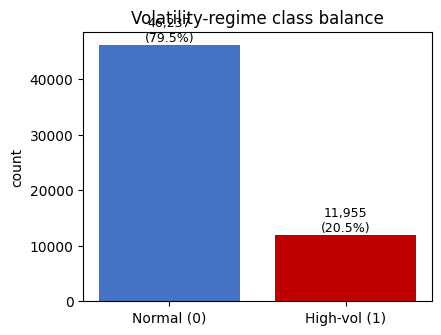

In [5]:
plots.plot_class_balance(labeled["label_highvol"]);

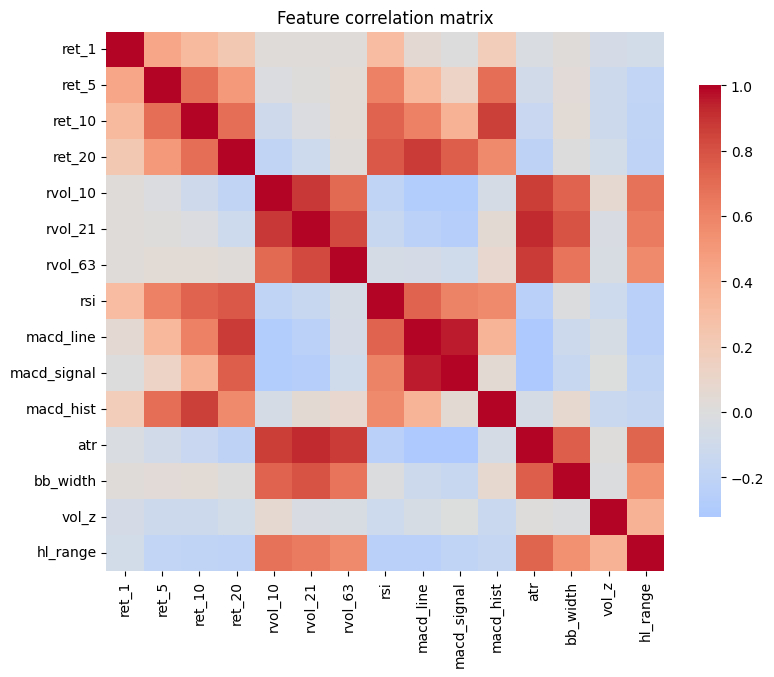

In [6]:
plots.plot_correlation(labeled, FEATURE_COLUMNS);

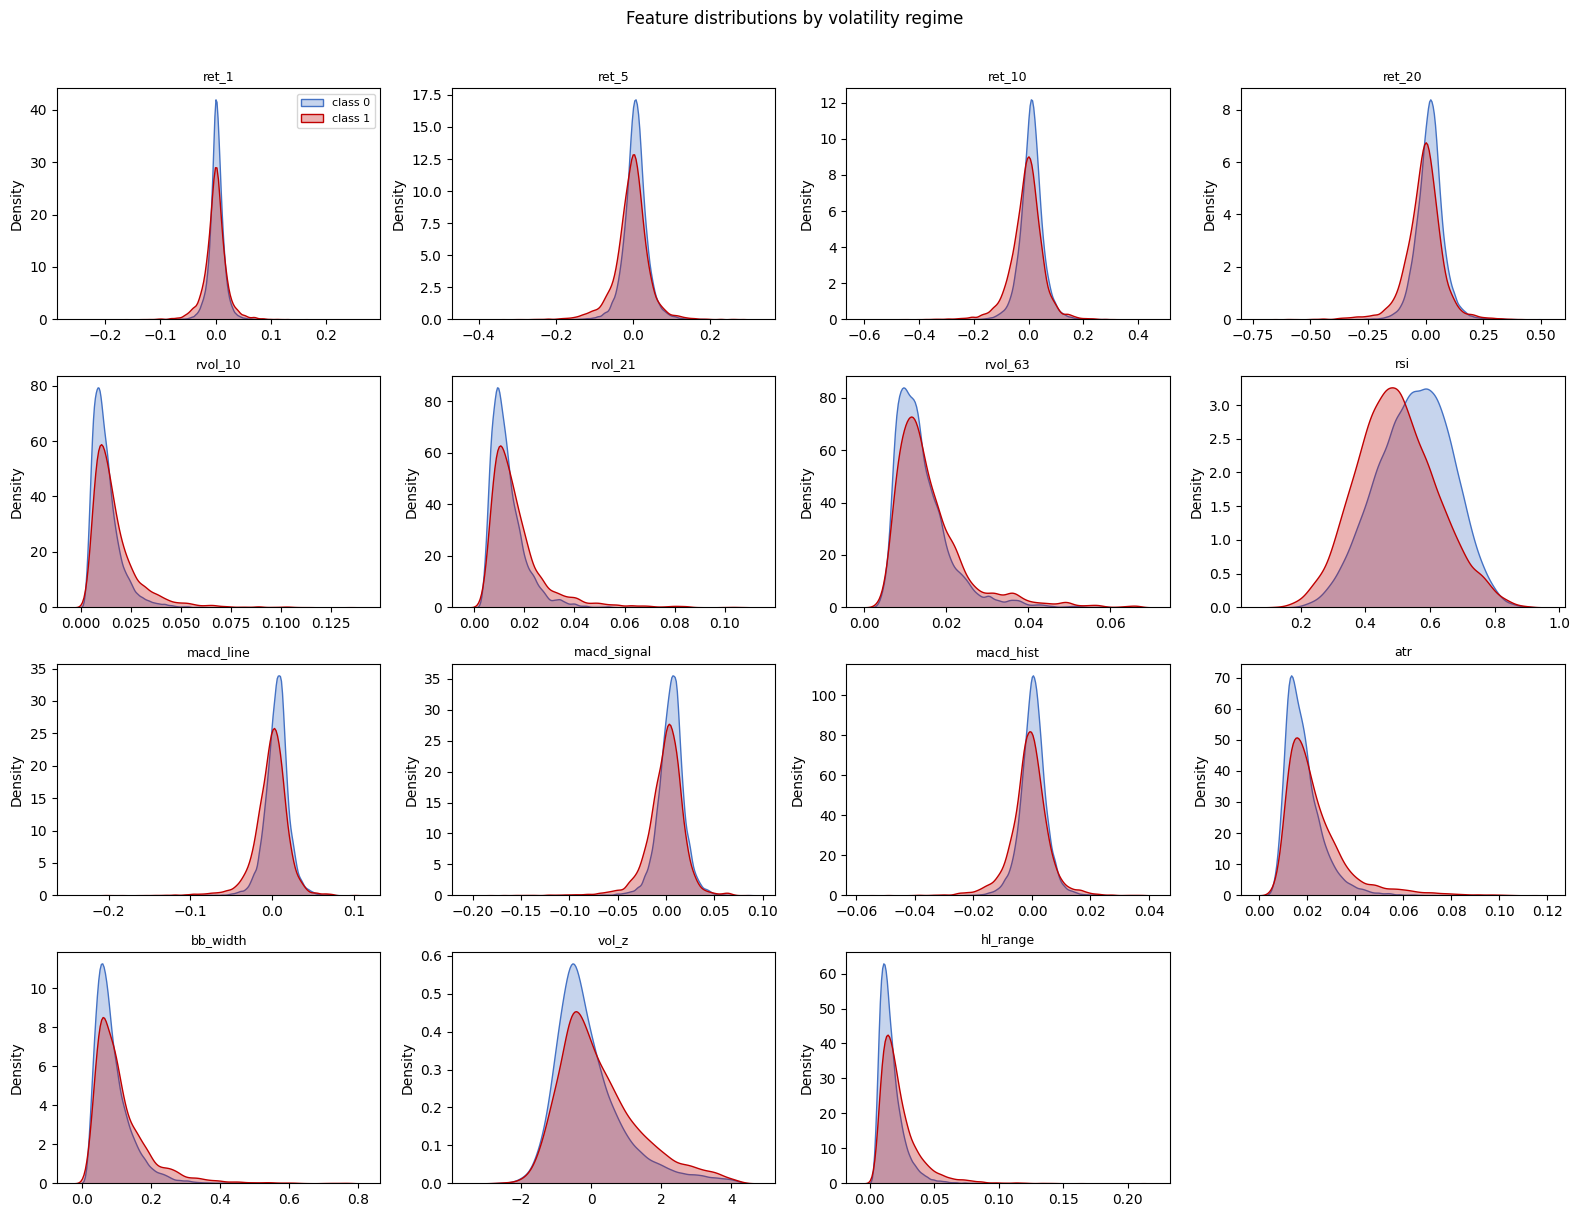

In [7]:
plots.plot_feature_by_label(labeled, FEATURE_COLUMNS);

In [8]:
adf = plots.adf_report(labeled, FEATURE_COLUMNS)
print("Stationarity (p<0.05 => stationary):")
adf.round(4)

Stationarity (p<0.05 => stationary):


,feature,adf_stat,p_value,stationary_5pct
0,ret_1,-31.9613,0.0,True
1,ret_5,-32.1561,0.0,True
2,ret_10,-32.2210,0.0,True
3,ret_20,-31.5956,0.0,True
4,rvol_10,-16.0670,0.0,True
5,rvol_21,-16.8374,0.0,True
6,rvol_63,-15.3654,0.0,True
7,rsi,-26.9831,0.0,True
8,macd_line,-25.3744,0.0,True
9,macd_signal,-29.5803,0.0,True


## 3. News-sentiment model — *Module 4 (to be implemented)*

Will import from `sentinel.models.sentiment` and fine-tune FinBERT on Financial PhraseBank + FiQA, e.g.:

```python
from sentinel.models.sentiment import finetune, evaluate
model = finetune.run(cfg)          # fine-tune FinBERT (HuggingFace)
evaluate.report(model, test_set)   # macro-F1, confusion matrix
```


## 4. Volatility circuit-breaker — *Module 5 (to be implemented)*

Will import from `sentinel.models.volatility` and train the neural classifier plus an XGBoost baseline on
the dataset built above, using the leakage-safe `time_split`:

```python
from sentinel.models.volatility import mlp, cnn_lstm, xgb_baseline
train, valid, test = time_split(dataset["date"], cfg.split.train_end,
                                cfg.split.valid_end, cfg.split.embargo_days)
```


## 5. Agentic pipeline + paper-simulator — *Module 6 (to be implemented)*

Will import from `sentinel.agents` (LangGraph nodes) and `sentinel.sim`, wiring the sentiment score and the
volatility circuit-breaker into the gated decision graph and running the offline paper-simulation.


## 6. Results & ablation — *Module 7 (to be implemented)*

The headline experiment: run the paper-simulator **with vs without** the volatility circuit-breaker and
compare maximum drawdown and Sharpe ratio to test the central hypothesis.
